In [1]:
from scripts.loader import * 

In [2]:
exp_data_folder = Path("../data")
dataset = DatasetGrail(exp_data_folder, "../data/config.xlsx")

In [4]:
index = dataset.create_index()
static = dataset.get_subset(
    task=["static"]
)
static.index

,id,speed,measurement,task
0,S01,0.0,static,static
1,S02,0.0,static,static
2,S03,0.0,static,static
3,S04,0.0,static,static
4,S05,0.0,static,static
5,S06,0.0,static,static
6,S07,0.0,static,static
7,S08,0.0,static,static
8,S09,0.0,static,static
9,S10,0.0,static,static


In [5]:
def get_weight(fy1, fy2):
    g = 9.80665  # m/s²

# Compute total vertical force over time
    f_total = fy1+fy2

# Average over the entire static trial
    weight_N = f_total.mean()
    mass_kg = weight_N / g
    return mass_kg
    

## compute mass

In [6]:
masses = []
for i in static:
    grf = i.grf_data
    mass = get_weight(grf.GRF_y_1, grf.GRF_y_2)
    print(mass)
    masses.append(mass)

68.23625211953713
62.082713347690294
88.5443117518763
79.5616751683051
70.17164825177314
85.2744207894121
50.10927821521929
66.61310037783724
75.23955982319839
102.93632943278651
87.28988802300967
51.286576949146024
90.1374977504499
64.57993917544438
73.96262068455721


## compute BMI

In [9]:
bmis = []
for i in static:
    grf = i.grf_data
    mass = get_weight(grf.GRF_y_1, grf.GRF_y_2)
    bmi = mass / (i.height)**2
    print(bmi)
    bmis.append(bmi)

21.536501742058174
21.48190773276481
26.153211174349092
28.189369036389284
24.86240371732325
24.915827842048824
18.405611832954747
24.766917154163167
24.015946829837652
26.523829377924322
23.434156090904366
19.30316419479319
30.117109743208893
23.720822470319334
25.896369414431295


## overview

In [44]:
participant_df = pd.DataFrame([list(static.index.id), masses, bmis]).T
participant_df.columns = ['id', 'mass', 'bmi']
participant_df.set_index('id', inplace=True)
participant_df = participant_df.apply(pd.to_numeric)

In [45]:
participant_df

,mass,bmi
id,,
S03,68.236252,21.536502
S04,62.082713,21.481908
S05,88.544312,26.153211
S07,79.561675,28.189369
S08,70.171648,24.862404
S09,85.274421,24.915828
S10,50.109278,18.405612
S11,66.613100,24.766917
S12,75.239560,24.015947


In [46]:
participant_df.describe()

,mass,bmi
count,15.000000,15.000000
mean,74.401721,24.221543
std,14.791211,3.130175
min,50.109278,18.405612
25%,65.596520,22.485329
50%,73.962621,24.766917
75%,86.282154,26.024790
max,102.936329,30.117110


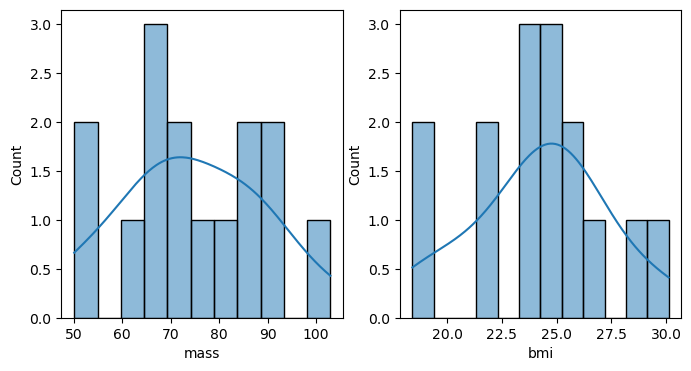

In [73]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

sns.histplot(participant_df['mass'], kde=True, ax=axes[0], binwidth = 5)
sns.histplot(participant_df['bmi'], kde=True, ax=axes[1], binwidth = 1)

plt.show()

In [16]:
import xarray as xr



arr = xr.DataArray(
    masses,
    dims=["person"]
)

In [17]:
arr.to_netcdf("mass_all.nc")

###### 